## Import thư viện

In [1]:
import WOEpyspark as woe
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import numpy as np

## Khởi tạo SparkSession

In [2]:
spark = SparkSession.builder \
    .appName("woe_analysis") \
    .master("local[4]") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .getOrCreate()

c:\Users\Asus\anaconda3\envs\sacom\Lib\site-packages\pyspark\testing\utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


## Load dữ liệu

In [3]:
# Load data
sdf = spark.read.parquet("feature_S5.parquet")

# Split train/test
train_sdf, test_sdf = woe.stratified_sklearnsplit(sdf, label_col="LABEL")


c:\Users\Asus\anaconda3\envs\sacom\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
c:\Users\Asus\anaconda3\envs\sacom\Lib\site-packages\pyspark\sql\pandas\conversion.py:659: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
c:\Users\Asus\anaconda3\envs\sacom\Lib\site-packages\pyspark\sql\pandas\conversion.py:936: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


## Tính raw WOE, IV với 100 bins

In [4]:
FEATURE_NAME = "NETCASHFLOW_AMT_D30_D180"

In [5]:
# Compute WoE/IV for a continuous variable (auto-binning)
df_woe_cont = woe.woe_continuous(train_sdf, FEATURE_NAME, "LABEL", n_bins=100)

c:\Users\Asus\anaconda3\envs\sacom\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


In [6]:
df_woe_cont.head(5)

,NETCASHFLOW_AMT_D30_D180,n_obs,prop_card,n_card,n_non_card,prop_n_obs,prop_n_card,prop_n_non_card,WoE,IV_bin,IV,diff_prop_card,diff_WoE
0,MISSING,89,0.000000,0.0,89.0,0.001451,0.001757,0.001464,0.182892,0.000054,0.440591,NaN,NaN
1,ZERO,919,0.001088,1.0,918.0,0.014985,0.005272,0.015022,-1.046999,0.010207,0.440591,0.001088,1.229891
2,"(-296884.3937054632,-296884.3937054632]",1,0.000000,0.0,1.0,0.000016,0.001757,0.000025,4.271666,0.007403,0.440591,0.001088,5.318665
3,"(-296884.3937054632,-104.53114463269719]",603,0.000000,0.0,603.0,0.009833,0.001757,0.009870,-1.725615,0.013999,0.440591,0.000000,5.997281
4,"(-104.53114463269719,-34.68891189805563]",603,0.000000,0.0,603.0,0.009833,0.001757,0.009870,-1.725615,0.013999,0.440591,0.000000,0.000000


## Vẽ biểu đồ WOE raw

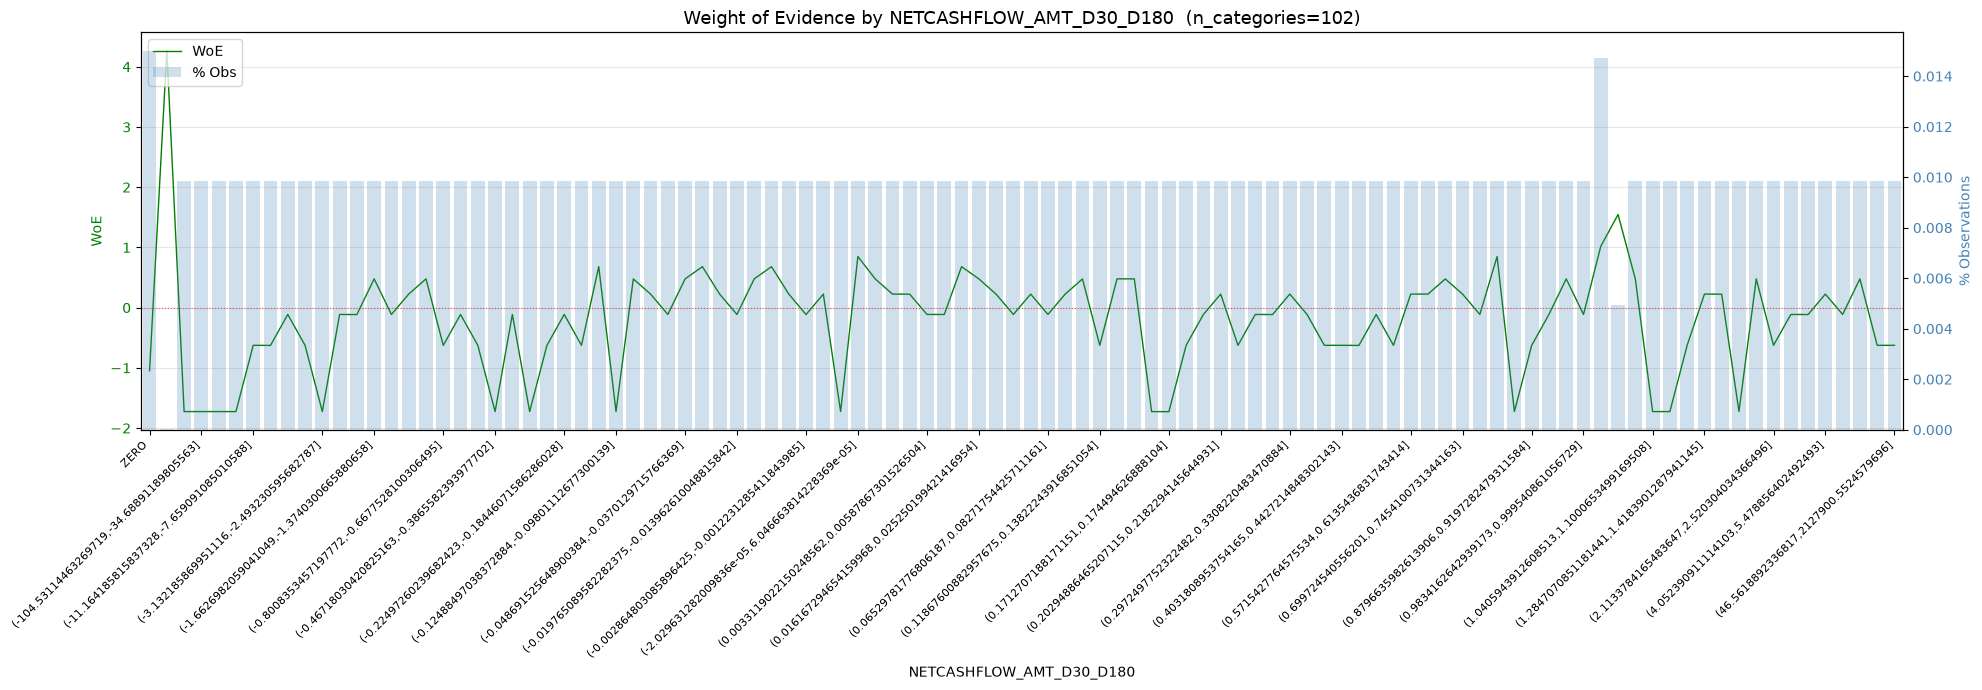

In [7]:
# Plot WoE chart (hiding MISSING for clearer view)
fig2 = woe.plot_woe_missing(df_woe_cont)

## Chia thủ công các bin

In [ ]:
# Define bins once
bins = [
    (-0.03, "(-inf, -0.03]"),
    (0.42, "(-0.03, 0.42]"),
    # (2_000_000_000, "(0.42, 2B]"),
    # (5_500_000_000, "(2B, 5.5B]"),
    (np.inf, "(0.42, +inf)")
]

# Bin info for saving
bin_info = {
    "feature": FEATURE_NAME,
    "edges": [-np.inf] + [b[0] for b in bins],
    "labels": [b[1] for b in bins],
    "special_bins": [
        "MISSING", 
        "ZERO"
        ]
}

col = F.col(FEATURE_NAME)

# comment dòng missing nếu muốn bỏ qua missing
bin_expr = (
    F
    # .when(col.isNull(), "MISSING")
    .when(col == 0, "ZERO")
)

for upper, label in bins:
    if np.isinf(upper):
        bin_expr = bin_expr.otherwise(label)
    else:
        bin_expr = bin_expr.when(col < upper, label)

train_sdf = train_sdf.withColumn(
    FEATURE_NAME + "_BIN",
    bin_expr
)
df_manual = woe.woe_discrete(train_sdf, FEATURE_NAME + "_BIN")

c:\Users\Asus\anaconda3\envs\sacom\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


## Vẽ biểu đồ WOE sau khi chia bins

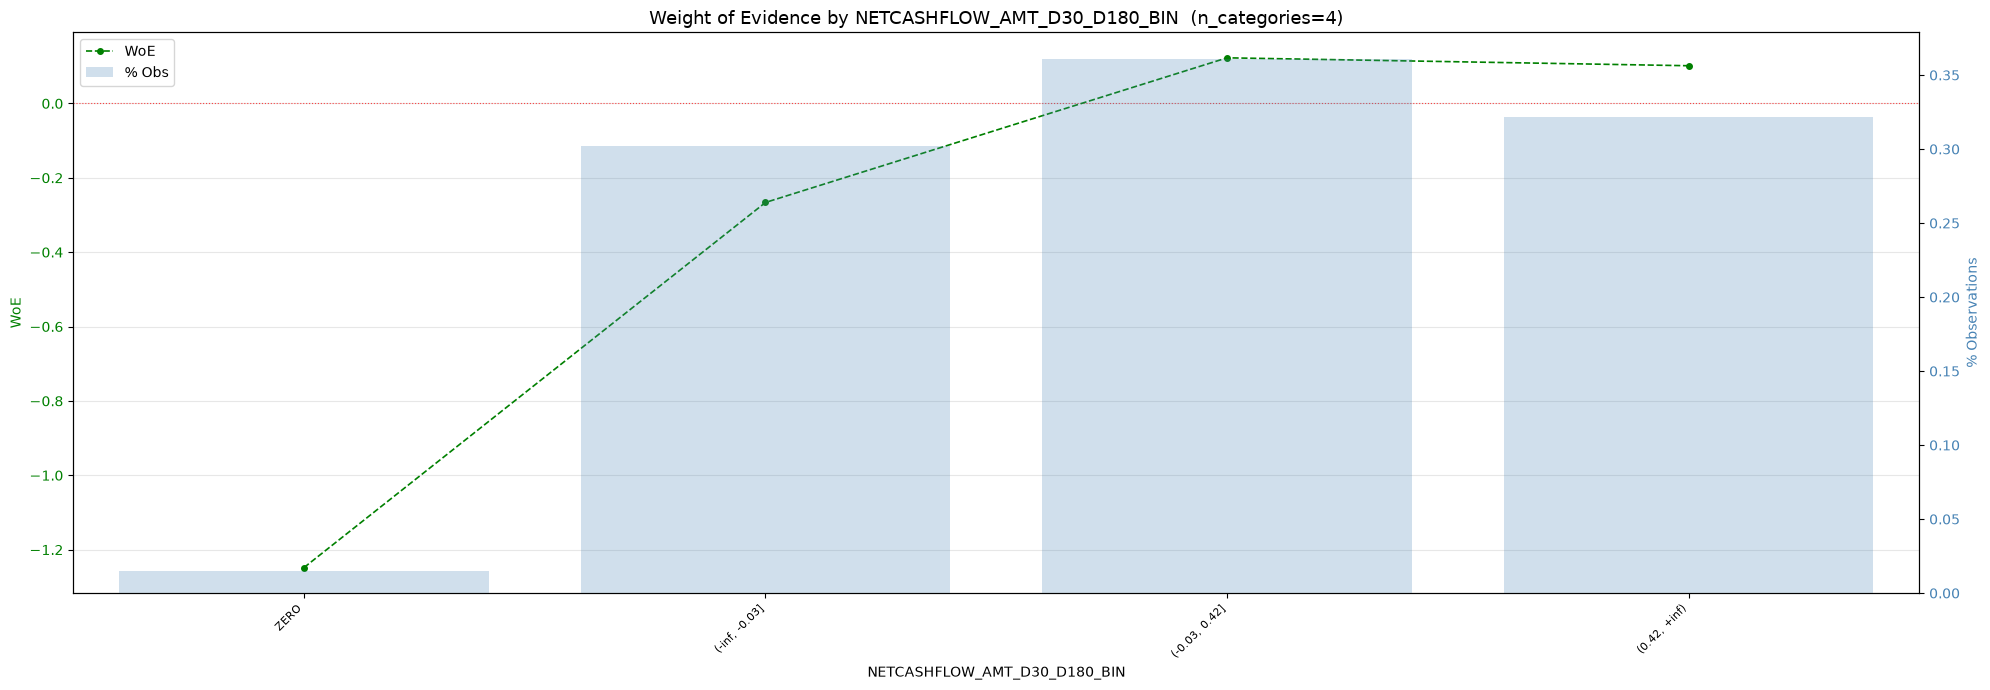

In [15]:
fig_manualdefine = woe.plot_woe(df_manual)


## Bảng kết quả của 3 trường hợp 
Bảng chứa MISSING, không chứa MISSING, và MISSING riêng

In [16]:
# Build 3 cases: FULL, MISSING_VS_REST, NO_MISSING
cases = woe.build_three_cases(df_manual, missing_label="MISSING")

print("Case A - Full IV:", cases["full"])
type(cases["full"])


[build_three_cases] Warning: no bin 'MISSING' found.
Case A - Full IV:   NETCASHFLOW_AMT_D30_D180_BIN  n_obs  prop_card  prop_n_obs  n_card  \
0                         ZERO    919   0.001088    0.014985     1.0   
1                (-inf, -0.03]  18533   0.002914    0.302200    54.0   
2                (-0.03, 0.42]  22128   0.004293    0.360820    95.0   
3                 (0.42, +inf)  19747   0.004203    0.321995    83.0   

   n_noncard  n_card_smooth  n_noncard_smooth  prop_n_card  prop_n_noncard  \
0      918.0          1.005           918.005     0.004313        0.015026   
1    18479.0         54.005         18479.005     0.231761        0.302468   
2    22033.0         95.005         22033.005     0.407712        0.360641   
3    19664.0         83.005         19664.005     0.356214        0.321865   

        WoE  diff_prop_card  diff_WoE  IV_detail        IV  
0 -1.248170             NaN       NaN   0.013372  0.041457  
1 -0.266269        0.001826  0.981901   0.018827  0.041

pandas.DataFrame

In [17]:
print("Case B - Missing vs Rest IV:", cases["missing_vs_rest"])

Case B - Missing vs Rest IV: Empty DataFrame
Columns: []
Index: []


In [18]:
print("Case C - No Missing IV:", cases["no_missing"])

Case C - No Missing IV:   NETCASHFLOW_AMT_D30_D180_BIN  n_obs  prop_card  prop_n_obs  n_card  \
0                         ZERO    919   0.001088    0.014985     1.0   
1                (-inf, -0.03]  18533   0.002914    0.302200    54.0   
2                (-0.03, 0.42]  22128   0.004293    0.360820    95.0   
3                 (0.42, +inf)  19747   0.004203    0.321995    83.0   

   n_noncard  n_card_smooth  n_noncard_smooth  prop_n_card  prop_n_noncard  \
0      918.0          1.005           918.005     0.004313        0.015026   
1    18479.0         54.005         18479.005     0.231761        0.302468   
2    22033.0         95.005         22033.005     0.407712        0.360641   
3    19664.0         83.005         19664.005     0.356214        0.321865   

        WoE  diff_prop_card  diff_WoE  IV_detail        IV  
0 -1.248170             NaN       NaN   0.013372  0.041457  
1 -0.266269        0.001826  0.981901   0.018827  0.041457  
2  0.122678        0.000090  0.021277   0

## Lưu kết quả và tổng hợp qua file CSV, HTML

In [19]:
# Create feature output folder
import os
output_dir = f"output/{FEATURE_NAME}"
os.makedirs(output_dir, exist_ok=True)

# CSV only
woe.save_iv_csv(cases, f"{output_dir}/iv_cases.csv")

# HTML with plot
woe.save_iv_html(
    iv_dict=cases,
    plots={"WoE_Chart": fig2, "Binned_Chart": fig_manualdefine},
    output_path=f"{output_dir}/iv_cases.html",
    title=f"IV Summary - {FEATURE_NAME}",
    bin_info=bin_info
)

'output/NETCASHFLOW_AMT_D30_D180/iv_cases.html'